In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

#ddw function which loads us correct .rec and .mrc files
from ddw.utils.mrctools import load_mrc_data

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def load_volume(path):
    vol = load_mrc_data(path)
    if isinstance(vol, torch.Tensor):
        vol = vol.cpu().numpy()
    return vol.astype(np.float32)


def compute_log_power_xz_slice_memory_efficient(vol, eps=1e-8):
    """
    Compute central XZ Fourier log-power slice without creating full 3D FFT volume.

    For volume shape (z, y, x), the ky=0 slice of the 3D FFT is equivalent
    to the 2D FFT of the projection summed over y.
    """
    vol = np.asarray(vol, dtype=np.float32)

    # remove DC bias
    vol = vol - np.mean(vol, dtype=np.float32)

    # ky=0 Fourier slice via projection over y
    proj_xz = np.sum(vol, axis=1, dtype=np.float32)  # shape: (z, x)

    F_xz = np.fft.fftshift(np.fft.fft2(proj_xz))
    log_power_xz = np.log1p(np.abs(F_xz) ** 2 + eps).astype(np.float32)

    return log_power_xz


def robust_limits(img, p_low=1, p_high=99):
    return np.percentile(img[np.isfinite(img)], [p_low, p_high])


def get_xy_slice(vol, z_idx=None):
    if z_idx is None:
        z_idx = vol.shape[0] // 2
    return vol[z_idx, :, :]


def get_xz_slice(vol, y_idx=None):
    if y_idx is None:
        y_idx = vol.shape[1] // 2
    return vol[:, y_idx, :]


def get_yz_slice(vol, x_idx=None):
    if x_idx is None:
        x_idx = vol.shape[2] // 2
    return vol[:, :, x_idx]


def get_plane_slice(vol, plane):
    if plane == "XY":
        return get_xy_slice(vol, z_idx=z_idx)
    elif plane == "XZ":
        return get_xz_slice(vol, y_idx=y_idx)
    elif plane == "YZ":
        return get_yz_slice(vol, x_idx=x_idx)
    else:
        raise ValueError("plane must be XY, XZ, or YZ")
        
        
def figsize_from_image(img, target_width=7.0, min_height=1.4, max_height=7.0):
    """
    Choose figure size from image shape.
    Keeps natural image aspect ratio.
    """
    h, w = img.shape
    aspect = h / w
    height = target_width * aspect
    height = np.clip(height, min_height, max_height)
    return (target_width, height)

In [3]:
# Input / baseline tomogram from filtered back-projection
tomo_input_path = Path("../tutorial/tutorial_data/tomo_all_frames.rec")

# DeepDeWedge refined tomogram from Step 3
tomo_refined_path = Path("../tutorial/tutorial_project/refined_tomograms/tomo_even_frames+tomo_odd_frames_refined.rec")

# OWN Model
tomo_own_path = Path("../../experiments/own_model/tomo_even_frames+tomo_odd_frames_mw50_avg_refined.rec")

tomo_input = load_volume(tomo_input_path)
tomo_refined = load_volume(tomo_refined_path)
tomo_own = load_volume(tomo_own_path)

print(type(tomo_input), tomo_input.shape)
print(type(tomo_refined), tomo_refined.shape)

<class 'numpy.ndarray'> (209, 1280, 550)
<class 'numpy.ndarray'> (209, 1280, 550)


In [ ]:
z_mid = tomo_input.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

vmin = -3 * tomo_input.std()
vmax =  3 * tomo_input.std()

axes[0].imshow(tomo_input[z_mid, :, :], cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Input FBP - XY slice")
axes[0].axis("off")

axes[1].imshow(tomo_refined[z_mid, :, :], cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("DeepDeWedge refined - XY slice")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# FBP 
case = "FBP"

z_idx = tomo_input.shape[0] // 2   # XY
y_idx = tomo_input.shape[1] // 2   # XZ
x_idx = tomo_input.shape[2] // 2   # YZ

tomo_plot = tomo_input

In [ ]:
# DDW
case = "DDW"

z_idx = tomo_refined.shape[0] // 2   # XY
y_idx = tomo_refined.shape[1] // 2   # XZ
x_idx = tomo_refined.shape[2] // 2   # YZ

tomo_plot = tomo_refined

In [4]:
# OWN
case = "OWN"

z_idx = tomo_own.shape[0] // 2   # XY
y_idx = tomo_own.shape[1] // 2   # XZ
x_idx = tomo_own.shape[2] // 2   # YZ

tomo_plot = tomo_own

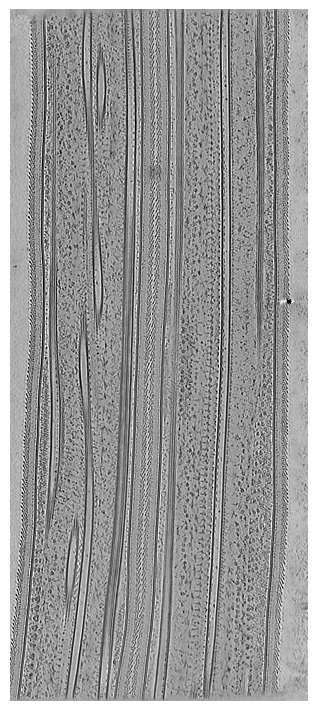

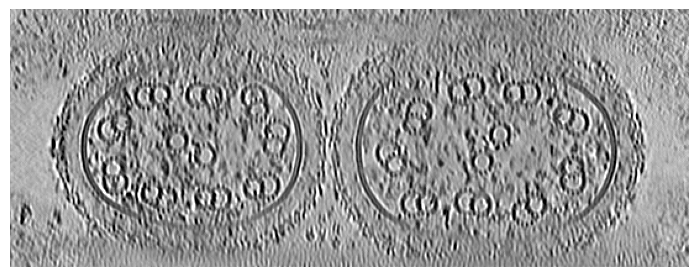

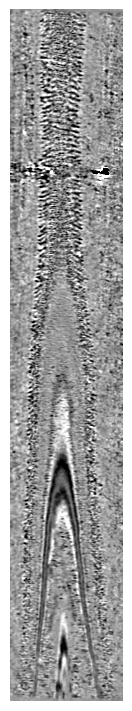

In [5]:
out_dir = Path("../../figures/baseline/slices")
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Step 1: extract slices only
# ------------------------------------------------------------

planes = ["XY", "XZ", "YZ"]

tomo_plot_slices = {
    plane: get_plane_slice(tomo_plot, plane).astype(np.float32)
    for plane in planes
}


# ------------------------------------------------------------
# Step 3: save each plane separately AND each panel individually
# ------------------------------------------------------------

def plot_single_overlay_panel(ax, bg, plane, label):
    """
    Plot one real-space absolute difference overlay panel.
    Uses the shared overlay_vmax and overlay_threshold from Step 2.
    """
    bg_vmin, bg_vmax = robust_limits(bg, 1, 99)

    im = ax.imshow(
        bg,
        cmap="gray",
        origin="lower",
        vmin=bg_vmin,
        vmax=bg_vmax,
        aspect="equal"
    )

    
    ax.axis("off")
    #add_axis_icon(ax, plane)

    return im


for plane in planes:

    bg = tomo_plot_slices[plane]

    # Paper-like orientation for YZ:
    # original YZ shape is (z, y) -> transpose to (y, z)
    # then horizontal = z, vertical = y
    
    if plane == "YZ":
        bg_plot = bg.T
        plane_plot = "YZ_paper"
    else:
        bg_plot = bg
        plane_plot = plane
    
    figsize = figsize_from_image(bg_plot, target_width=7.0)

    # --------------------------------------------------------
    # B) Save individual panels: one angle per image
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=True
    )

    plot_single_overlay_panel(
        ax=ax,
        bg=bg_plot,
        plane=plane_plot,
        label=None
    )

    save_png = out_dir / f"{case}_{plane}_Slice.png"

    plt.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
        
    plt.show()

1.7231421
32.951424


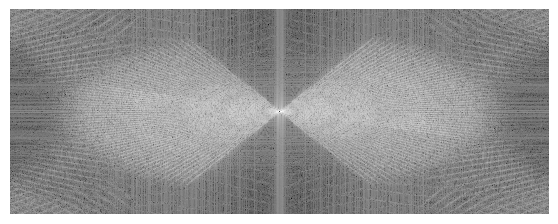

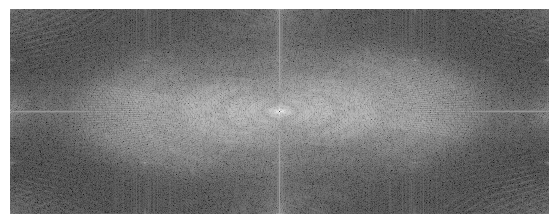

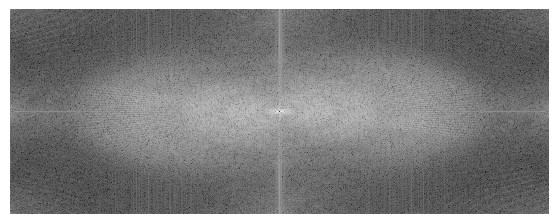

In [6]:
# ------------------------------------------------------------
# Step 1: compute Fourier XZ slices
# ------------------------------------------------------------

log_power_input_xz = compute_log_power_xz_slice_memory_efficient(tomo_input)
log_power_refined_xz = compute_log_power_xz_slice_memory_efficient(tomo_refined)
log_power_own_xz = compute_log_power_xz_slice_memory_efficient(tomo_own)

# Use same contrast range for fair comparison
fourier_vmin = min(log_power_input_xz.min(), log_power_refined_xz.min(), log_power_own_xz.min())
fourier_vmax = max(log_power_input_xz.max(), log_power_refined_xz.max(), log_power_own_xz.max())
print(fourier_vmin)
print(fourier_vmax)

log_power_plot = [log_power_input_xz, log_power_refined_xz, log_power_own_xz]
cases = ["FBP", "DDW", "OWN"]

out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Step 2: save clean Fourier panels individually
# ------------------------------------------------------------

for img, case in zip(log_power_plot, cases):

    # Natural aspect ratio
    h, w = img.shape
    target_width = 7.0
    fig_height = target_width * h / w

    fig, ax = plt.subplots(figsize=(target_width, fig_height))

    im = ax.imshow(
        img,
        cmap="gray",
        origin="lower",
        interpolation="nearest",
        vmin=fourier_vmin,
        vmax=fourier_vmax,
        aspect="equal"
    )

    # Optional: only if you want wedge contours
    # add_wedge_contours(ax)

    ax.axis("off")

    save_png = out_dir / f"{case}_Fourier_XZ_Slice.png"

    plt.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()

### Power Spectrum Analysis

In [ ]:
#Transforms the whole volume to Fourier space
''''
def compute_power_spectrum(volume):
    """
    Compute centered 3D power spectrum of a real-space volume.

    Input:
        volume: 3D numpy array, shape usually (z, y, x)

    Output:
        power: 3D numpy array, same shape, centered Fourier power spectrum
    """
    # 3D Fourier transform
    fft_volume = np.fft.fftn(volume)

    # Shift zero frequency to the center for visualization
    fft_volume_shifted = np.fft.fftshift(fft_volume)

    # Power spectrum = squared magnitude of Fourier coefficients
    power = np.abs(fft_volume_shifted) ** 2

    return power


power_input = compute_power_spectrum(tomo_input)
power_refined = compute_power_spectrum(tomo_refined)

print(power_input.shape)
print(power_refined.shape)
'''

In [ ]:
#------------------
# Combined plot
#------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(log_power_input_xz, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Input FBP\ncentral XZ Fourier power slice")
axes[0].axis("off")

axes[1].imshow(log_power_refined_xz, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("DeepDeWedge refined\ncentral XZ Fourier power slice")
axes[1].axis("off")


os.makedirs("../../figures", exist_ok=True)
save_path = "../../figures/FBP_DDW_Fourier_Power_Slice.png"

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

#------------------
# Single Plot
#------------------

# Compute central XZ Fourier power slice for input FBP
log_power_input_xz = compute_log_power_xz_slice_memory_efficient(tomo_input)

# ------------------
# Report-style single plot
# ------------------


plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

cm = 1 / 2.54

fig, ax = plt.subplots(figsize=(5.2 * cm, 5.2 * cm))

ax.imshow(
    log_power_input_xz,
    cmap="gray",
    origin="lower",
    interpolation="nearest"
)

ax.set_aspect("equal")

# Minimal Fourier-space axes
ax.set_xlabel(r"$k_x$", labelpad=1)
ax.set_ylabel(r"$k_z$", labelpad=1)

# No numerical ticks for a clean schematic/report figure
ax.set_xticks([])
ax.set_yticks([])

# Thin frame
for spine in ax.spines.values():
    spine.set_linewidth(0.6)

os.makedirs("../../figures", exist_ok=True)

save_path_pdf = "../../figures/FBP_Fourier_Power_XZ_report.pdf"
save_path_png = "../../figures/FBP_Fourier_Power_XZ_report.png"

fig.savefig(save_path_pdf, bbox_inches="tight")
fig.savefig(save_path_png, dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#Fourier Shell Correlation
def compute_fsc(vol1, vol2, num_shells=None):
    """
    Compute Fourier Shell Correlation between two 3D volumes.

    Parameters
    ----------
    vol1, vol2 : np.ndarray
        3D volumes with the same shape, usually ordered as (z, y, x).
    num_shells : int or None
        Number of radial Fourier shells. If None, use half the smallest dimension.

    Returns
    -------
    shell_frequencies : np.ndarray
        Normalized shell frequencies from low to high frequency.
    fsc_values : np.ndarray
        FSC values for each shell.
    """
    assert vol1.shape == vol2.shape, "Volumes must have the same shape."

    # Fourier transform and shift zero frequency to center
    F1 = np.fft.fftshift(np.fft.fftn(vol1))
    F2 = np.fft.fftshift(np.fft.fftn(vol2))

    shape = vol1.shape

    if num_shells is None:
        num_shells = min(shape) // 2

    # Create coordinate grid in Fourier space
    z, y, x = np.indices(shape)
    center = np.array(shape) // 2

    # Radial distance from Fourier center
    r = np.sqrt(
        (z - center[0])**2 +
        (y - center[1])**2 +
        (x - center[2])**2
    )

    r_max = min(shape) // 2
    shell_edges = np.linspace(0, r_max, num_shells + 1)

    shell_frequencies = []
    fsc_values = []

    for i in range(num_shells):
        shell_mask = (r >= shell_edges[i]) & (r < shell_edges[i + 1])

        if np.sum(shell_mask) == 0:
            shell_frequencies.append(np.nan)
            fsc_values.append(np.nan)
            continue

        F1_shell = F1[shell_mask]
        F2_shell = F2[shell_mask]

        numerator = np.sum(F1_shell * np.conj(F2_shell))
        denominator = np.sqrt(
            np.sum(np.abs(F1_shell)**2) *
            np.sum(np.abs(F2_shell)**2)
        )

        if denominator == 0:
            fsc = np.nan
        else:
            fsc = np.real(numerator / denominator)

        shell_center = 0.5 * (shell_edges[i] + shell_edges[i + 1])
        normalized_frequency = shell_center / r_max

        shell_frequencies.append(normalized_frequency)
        fsc_values.append(fsc)

    return np.array(shell_frequencies), np.array(fsc_values)

In [ ]:
tomo_even = load_volume("../tutorial/tutorial_data/tomo_even_frames.rec")
tomo_odd = load_volume("../tutorial/tutorial_data/tomo_odd_frames.rec")

In [ ]:
freqs, fsc_values = compute_fsc(tomo_even, tomo_odd)

plt.figure(figsize=(7, 5))
plt.plot(freqs, fsc_values, label="FBP even vs odd")
plt.axhline(0.143, linestyle="--", label="0.143 criterion")
plt.axhline(0.5, linestyle="--", label="0.5 criterion")

plt.xlabel("Normalized spatial frequency")
plt.ylabel("FSC")
plt.title("Fourier Shell Correlation: even vs odd FBP")
plt.ylim(-0.1, 1.05)
plt.legend()
plt.tight_layout()

os.makedirs("../../figures", exist_ok=True)
save_path = "../../figures/FSC_even_odd_FBP.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", os.path.abspath(save_path))
print("File exists:", os.path.exists(save_path))

In [ ]:
freqs, fsc_values = compute_fsc(tomo_input, tomo_refined)

plt.figure(figsize=(7, 5))
plt.plot(freqs, fsc_values, label="FBP vs Refined")
plt.axhline(0.143, linestyle="--", label="0.143 criterion")
plt.axhline(0.5, linestyle="--", label="0.5 criterion")

plt.xlabel("Normalized spatial frequency")
plt.ylabel("FSC")
plt.title("Fourier Shell Correlation: FBP vs Refined")
plt.ylim(-0.1, 1.05)
plt.legend()
plt.tight_layout()

os.makedirs("../../figures", exist_ok=True)
save_path = "../../figures/FSC_FBP_Refined.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", os.path.abspath(save_path))
print("File exists:", os.path.exists(save_path))

### Resolution Calculation

In [ ]:
voxel_size_A = 14.13 #in Angstrom taken from paper

def estimate_fsc_resolution(freqs, fsc_values, threshold, voxel_size_angstrom=14.13):
    """
    Estimate resolution from the FSC threshold crossing.

    Parameters
    ----------
    freqs : array
        Normalized spatial frequencies, where 1.0 corresponds to Nyquist.
    fsc_values : array
        FSC values.
    threshold : float
        FSC threshold, e.g. 0.5 or 0.143.
    voxel_size_angstrom : float or None
        Voxel size in Angstrom. If None, only resolution in voxels is returned.

    Returns
    -------
    result : dict
        Contains threshold, crossing_frequency, resolution_voxels,
        and resolution_angstrom.
    """
    freqs = np.asarray(freqs, dtype=float)
    fsc_values = np.asarray(fsc_values, dtype=float)

    valid = np.isfinite(freqs) & np.isfinite(fsc_values)
    freqs = freqs[valid]
    fsc_values = fsc_values[valid]

    # Find the first point where FSC drops below the threshold
    below = np.where(fsc_values < threshold)[0]

    if len(below) == 0:
        return {
            "threshold": threshold,
            "crossing_frequency": np.nan,
            "resolution_voxels": np.nan,
            "resolution_angstrom": np.nan,
            "note": f"FSC never drops below {threshold} within sampled frequencies."
        }

    idx = below[0]

    if idx == 0:
        f_cross = freqs[0]
    else:
        # Linear interpolation between the last point above and first point below
        f1, f2 = freqs[idx - 1], freqs[idx]
        y1, y2 = fsc_values[idx - 1], fsc_values[idx]

        if y2 == y1:
            f_cross = f2
        else:
            f_cross = f1 + (threshold - y1) * (f2 - f1) / (y2 - y1)

    resolution_voxels = 2.0 / f_cross if f_cross > 0 else np.nan

    if voxel_size_angstrom is None:
        resolution_angstrom = np.nan
    else:
        resolution_angstrom = resolution_voxels * voxel_size_angstrom

    return {
        "threshold": threshold,
        "crossing_frequency": f_cross,
        "resolution_voxels": resolution_voxels,
        "resolution_angstrom": resolution_angstrom,
        "note": "ok"
    }


res_05 = estimate_fsc_resolution(freqs, fsc_values, threshold=0.5, voxel_size_angstrom=voxel_size_A)
res_0143 = estimate_fsc_resolution(freqs, fsc_values, threshold=0.143, voxel_size_angstrom=voxel_size_A)

for res in [res_05, res_0143]:
    print("\nFSC threshold:", res["threshold"])
    print("crossing frequency:", res["crossing_frequency"])
    print("resolution [voxels]:", res["resolution_voxels"])
    print("resolution [Å]:", res["resolution_angstrom"])
    print("note:", res["note"])